# Распознавание породы по фотографии, v2

Классификатор всех 25 пород собак из Oxford-IIIT Pet. Двадцать шестой класс — «другие»: двенадцать пород кошек из того же датасета.

Обучение — дообучение последнего слоя pretrained ResNet18 на Oxford-IIIT Pet. В первом ноутбуке чужая собака всё равно получала одну из пяти пород, чаще бигля. Здесь у каждой собаки из датасета свой класс, а кошки размечены как «другие».

Распознавание своего фото — отдельный прогон: из `dog_breeds_v2.pth` поднимаются только веса, архитектуру задаёт код. Файл `dog_breeds.pth` из первого ноутбука не перезаписывается.

Ядро ноутбука — **Python (lecture2)**, интерпретатор `lecture2/.venv` (Python 3.12). Пакеты уже стоят в этом окружении: torch, torchvision, pillow, matplotlib, ipykernel. Зависимости записаны в `lecture2/requirements.txt`.

Ноутбук запускать из папки `lecture2`. Своё фото положить рядом и указать путь в `image_path`. На лекции это был `D:\dog.jpg`.

In [38]:
import sys
from pathlib import Path

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from torchvision.models import resnet18, ResNet18_Weights
from PIL import Image

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

image_path = Path("photos/Beagle_1.jpg")
checkpoint_path = Path("dog_breeds_v2.pth")

print("device:", device)
print("фото:", image_path.resolve())
print("чекпоинт:", checkpoint_path.resolve())

device: mps
фото: /Users/madmarchello/dev_projects/aisec-hse/python/lecture2/photos/Beagle_1.jpg
чекпоинт: /Users/madmarchello/dev_projects/aisec-hse/python/lecture2/dog_breeds_v2.pth


## Preprocessing

`weights.transforms()` приводит картинку к тому виду, на котором училась ResNet18: resize, crop, тензор float32 и нормализация. Та же функция нужна и для обучающих фото, и для своего файла.

In [39]:
weights = ResNet18_Weights.DEFAULT
transform = weights.transforms()

## Двадцать шесть классов из Oxford-IIIT Pet

В датасете 37 классов: 25 пород собак и 12 пород кошек. Собаки получают индексы 0…24. Все кошки склеиваются в класс 25, «другие». JPEG не копируются: `BreedsWithOther` подменяет метку на лету.

Кадров «других» больше, чем любой одной породы. Веса loss обратно пропорциональны числу примеров, иначе модель чаще отвечала бы «другие».

In [40]:
train_all = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    download=True,
)
test_all = datasets.OxfordIIITPet(
    root="./data",
    split="test",
    target_types="category",
    download=True,
)

print(len(train_all), len(test_all))
print(train_all.classes)

breeds = [
    "American Bulldog",
    "American Pit Bull Terrier",
    "Basset Hound",
    "Beagle",
    "Boxer",
    "Chihuahua",
    "English Cocker Spaniel",
    "English Setter",
    "German Shorthaired",
    "Great Pyrenees",
    "Havanese",
    "Japanese Chin",
    "Keeshond",
    "Leonberger",
    "Miniature Pinscher",
    "Newfoundland",
    "Pomeranian",
    "Pug",
    "Saint Bernard",
    "Samoyed",
    "Scottish Terrier",
    "Shiba Inu",
    "Staffordshire Bull Terrier",
    "Wheaten Terrier",
    "Yorkshire Terrier",
]
other_name = "другие"
classes = breeds + [other_name]
other_id = len(breeds)

name_to_old = {
    name: i
    for i, name in enumerate(train_all.classes)
}
selected_old = [
    name_to_old[name]
    for name in breeds
]
old_to_new = {
    old: new
    for new, old in enumerate(selected_old)
}
print(old_to_new)
print("другие:", other_id)


def to_new_label(old_y):
    return old_to_new.get(old_y, other_id)


class BreedsWithOther(Dataset):
    def __init__(self, base, transform):
        self.base = base
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, i):
        image, old_y = self.base[i]
        image = self.transform(image)
        return image, to_new_label(old_y)


# Метки уже лежат в датасете, JPEG для подсчёта открывать не нужно.
label_counts = [0] * len(classes)
for old_y in train_all._labels:
    label_counts[to_new_label(old_y)] += 1

total_labels = sum(label_counts)
class_weights = torch.tensor(
    [
        total_labels / (len(classes) * count)
        for count in label_counts
    ],
    dtype=torch.float32,
)

print("примеров по классам:")
for name, count, weight in zip(classes, label_counts, class_weights.tolist()):
    print(f"{name:<28} {count:<5} вес {weight:.3f}")

train_ds = BreedsWithOther(train_all, transform)
test_ds = BreedsWithOther(test_all, transform)

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
)
test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
)

X, y = next(iter(train_loader))
print(X.shape)  # [32, 3, 224, 224]
print(y.shape)  # [32]
print("train", len(train_ds), "test", len(test_ds))

3680 3669
['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']
{1: 0, 2: 1, 3: 2, 4: 3, 8: 4, 10: 5, 12: 6, 13: 7, 14: 8, 15: 9, 16: 10, 17: 11, 18: 12, 19: 13, 21: 14, 22: 15, 24: 16, 25: 17, 28: 18, 29: 19, 30: 20, 31: 21, 34: 22, 35: 23, 36: 24}
другие: 25
примеров по классам:
American Bulldog             100   вес 1.415
American Pit Bull Terrier    100   вес 1.415
Basset Hound                 100   вес 1.415
Beagle                       100   вес 1.415
Boxer      

## Модель

Слои ResNet18, уже обученные на ImageNet, заморожены. Меняется только новый классификатор: 512 признаков → 26 классов. Оптимизатор видит только `model.fc.parameters()`. Веса loss взяты из предыдущей ячейки: редкая порода влияет на ошибку так же, как большой класс «другие».

In [41]:
model = resnet18(weights=weights)

for p in model.parameters():
    p.requires_grad = False

model.fc = nn.Linear(
    model.fc.in_features,
    len(classes),
)
model = model.to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device),
)
optimizer = torch.optim.SGD(
    model.fc.parameters(),
    lr=0.01,
    momentum=0.9,
)

## Обучение

Пять эпох. На каждом батче: обнулить градиент, посчитать logits, loss, `backward`, шаг оптимизатора. Loss последнего батча эпохи складывается в `epoch_losses` — по этому списку потом рисуется диаграмма. Если `dog_breeds_v2.pth` уже есть и заново учить не нужно, обучение, проверку и сохранение можно пропустить и перейти к блоку accuracy.

In [42]:
epoch_losses = []
for epoch in range(5):
    model.train()
    for X, y in train_loader:
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

    epoch_losses.append(loss.item())
    print(
        f"epoch={epoch + 1} "
        f"loss={loss.item():.4f}"
    )

epoch=1 loss=0.3290
epoch=2 loss=0.2535
epoch=3 loss=0.1300
epoch=4 loss=0.1354
epoch=5 loss=0.1736


## Проверка на test

Без `backward()` и `optimizer.step()`: тест не меняет веса. Кроме общей accuracy печатается доля верных ответов по каждому классу — так видно, что «другие» не съели отдельные породы.

In [43]:
model.eval()
correct = 0
total = 0
correct_by_class = [0] * len(classes)
total_by_class = [0] * len(classes)

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        y = y.to(device)

        logits = model(X)
        pred = logits.argmax(dim=1)
        match = pred == y

        correct += match.sum().item()
        total += y.size(0)

        for class_id in range(len(classes)):
            mask = y == class_id
            total_by_class[class_id] += mask.sum().item()
            correct_by_class[class_id] += (match & mask).sum().item()

accuracy = correct / total
print(f"accuracy = {accuracy:.2%}")
print()
for name, ok, n in zip(classes, correct_by_class, total_by_class):
    print(f"{name:<28} {ok / n:.2%}  ({ok}/{n})")

accuracy = 90.30%

American Bulldog             93.00%  (93/100)
American Pit Bull Terrier    33.00%  (33/100)
Basset Hound                 76.00%  (76/100)
Beagle                       93.00%  (93/100)
Boxer                        60.61%  (60/99)
Chihuahua                    81.00%  (81/100)
English Cocker Spaniel       93.00%  (93/100)
English Setter               95.00%  (95/100)
German Shorthaired           96.00%  (96/100)
Great Pyrenees               91.00%  (91/100)
Havanese                     99.00%  (99/100)
Japanese Chin                98.00%  (98/100)
Keeshond                     100.00%  (99/99)
Leonberger                   99.00%  (99/100)
Miniature Pinscher           87.00%  (87/100)
Newfoundland                 92.00%  (92/100)
Pomeranian                   95.00%  (95/100)
Pug                          95.00%  (95/100)
Saint Bernard                95.00%  (95/100)
Samoyed                      99.00%  (99/100)
Scottish Terrier             97.98%  (97/99)
Shiba Inu        

## Сохранение

В файле веса всей сети, список из 26 классов и `epoch_losses` — loss последнего батча каждой эпохи. Описание слоёв файл не хранит: при загрузке ResNet18 и замену `fc` нужно собрать в коде заново.

In [44]:
torch.save(
    {
        "model_state": model.state_dict(),
        "classes": classes,
        "epoch_losses": epoch_losses,
    },
    checkpoint_path,
)
print("сохранено:", checkpoint_path.resolve())

сохранено: /Users/madmarchello/dev_projects/aisec-hse/python/lecture2/dog_breeds_v2.pth


## Accuracy по классам

Блок читает уже обученный `dog_breeds_v2.pth` и заново прогоняет test. Веса не меняются: нет `backward()` и шага оптимизатора.

Первая ячейка печатает loss последнего батча по эпохам, общую accuracy и долю верных по каждому классу. Вторая рисует три диаграммы: loss, accuracy по классам и матрицу ошибок. В матрице строка — истинный класс, столбец — предсказание, подпись — доля кадров этой строки. Породы ниже 90% на столбчатой диаграмме отмечены отдельно.


In [45]:
try:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )
except TypeError:
    checkpoint = torch.load(checkpoint_path, map_location=device)

classes = checkpoint["classes"]
epoch_losses = checkpoint["epoch_losses"]

model = resnet18(weights=None)
model.fc = nn.Linear(
    model.fc.in_features,
    len(classes),
)
model.load_state_dict(checkpoint["model_state"])
model = model.to(device)
model.eval()

correct = 0
total = 0
correct_by_class = [0] * len(classes)
total_by_class = [0] * len(classes)
confusion = torch.zeros(len(classes), len(classes), dtype=torch.int64)

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        y = y.to(device)
        pred = model(X).argmax(dim=1)
        match = pred == y

        correct += match.sum().item()
        total += y.size(0)

        for class_id in range(len(classes)):
            mask = y == class_id
            total_by_class[class_id] += int(mask.sum().item())
            correct_by_class[class_id] += int((match & mask).sum().item())

        for true_id, pred_id in zip(y.tolist(), pred.tolist()):
            confusion[true_id, pred_id] += 1

accuracy = correct / total
print("loss последнего батча по эпохам:")
for epoch, value in enumerate(epoch_losses, start=1):
    print(f"epoch={epoch} loss={value:.4f}")
print()
print(f"accuracy = {accuracy:.2%}")
print()
for name, ok, n in zip(classes, correct_by_class, total_by_class):
    print(f"{name:<28} {ok / n:.2%}  ({ok}/{n})")


loss последнего батча по эпохам:
epoch=1 loss=0.3290
epoch=2 loss=0.2535
epoch=3 loss=0.1300
epoch=4 loss=0.1354
epoch=5 loss=0.1736

accuracy = 90.30%

American Bulldog             93.00%  (93/100)
American Pit Bull Terrier    33.00%  (33/100)
Basset Hound                 76.00%  (76/100)
Beagle                       93.00%  (93/100)
Boxer                        60.61%  (60/99)
Chihuahua                    81.00%  (81/100)
English Cocker Spaniel       93.00%  (93/100)
English Setter               95.00%  (95/100)
German Shorthaired           96.00%  (96/100)
Great Pyrenees               91.00%  (91/100)
Havanese                     99.00%  (99/100)
Japanese Chin                98.00%  (98/100)
Keeshond                     100.00%  (99/99)
Leonberger                   99.00%  (99/100)
Miniature Pinscher           87.00%  (87/100)
Newfoundland                 92.00%  (92/100)
Pomeranian                   95.00%  (95/100)
Pug                          95.00%  (95/100)
Saint Bernard       

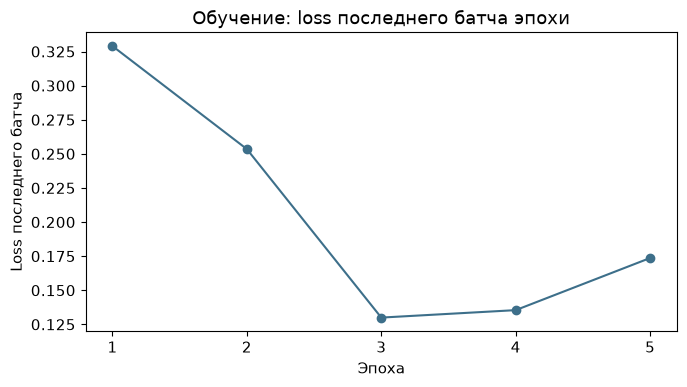

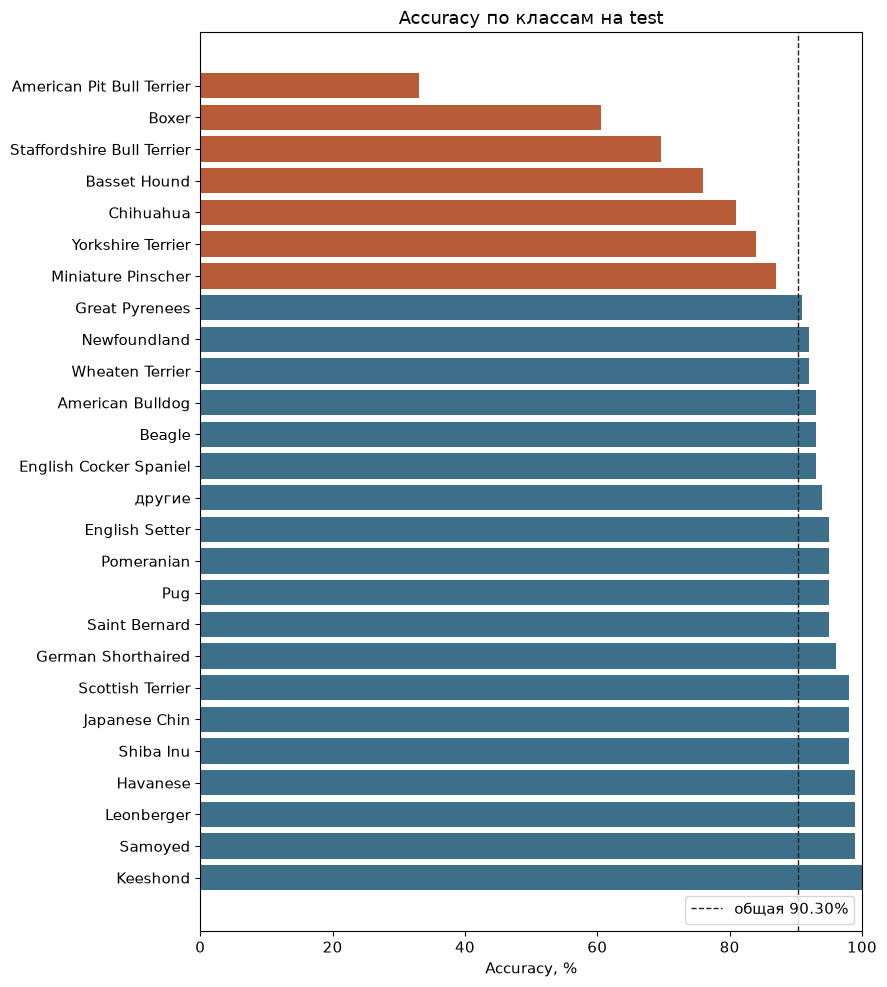

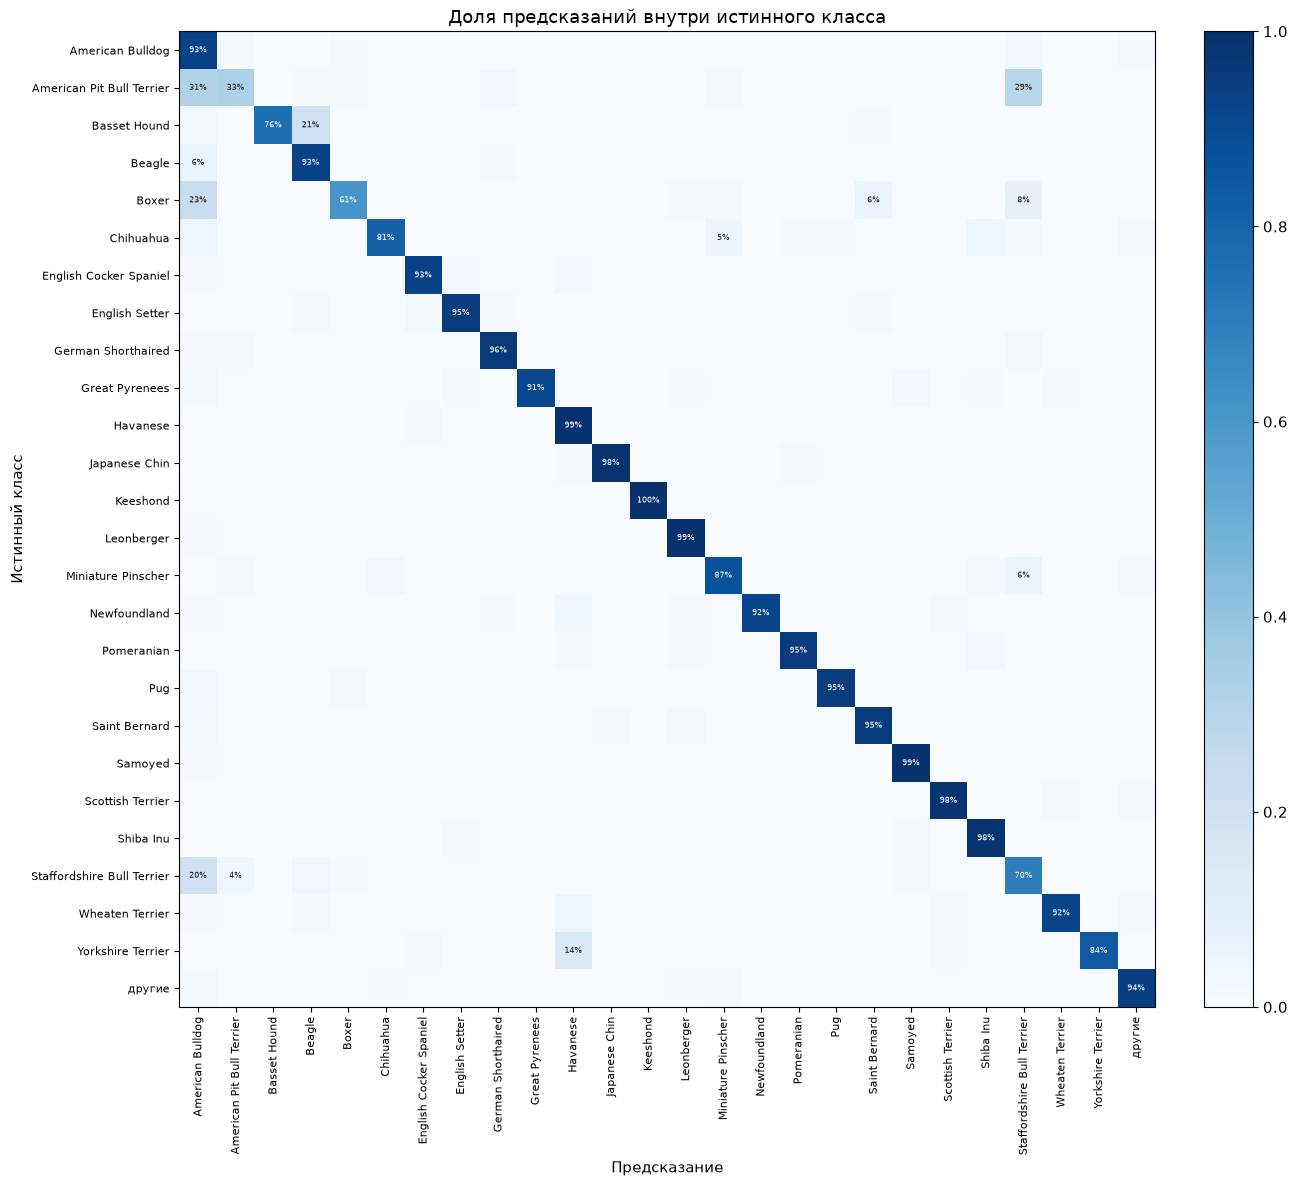

In [46]:
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 11

fig, ax = plt.subplots(figsize=(7, 4))
epochs = list(range(1, len(epoch_losses) + 1))
ax.plot(epochs, epoch_losses, marker="o", color="#3d6f8a")
ax.set_xticks(epochs)
ax.set_xlabel("Эпоха")
ax.set_ylabel("Loss последнего батча")
ax.set_title("Обучение: loss последнего батча эпохи")
fig.tight_layout()
plt.show()

accuracies = [
    ok / n
    for ok, n in zip(correct_by_class, total_by_class)
]
order = sorted(range(len(classes)), key=lambda i: accuracies[i])
names = [classes[i] for i in order]
values = [accuracies[i] * 100 for i in order]
colors = ["#b85c38" if value < 90 else "#3d6f8a" for value in values]

fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(names, values, color=colors)
ax.axvline(
    accuracy * 100,
    color="#222222",
    linestyle="--",
    linewidth=1,
    label=f"общая {accuracy:.2%}",
)
ax.set_xlim(0, 100)
ax.set_xlabel("Accuracy, %")
ax.set_title("Accuracy по классам на test")
ax.legend(loc="lower right")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

share = confusion.float()
share = share / share.sum(dim=1, keepdim=True).clamp(min=1)
data = share.numpy()

fig, ax = plt.subplots(figsize=(14, 12))
image = ax.imshow(data, vmin=0, vmax=1, cmap="Blues")
ax.set_xticks(range(len(classes)), classes, rotation=90, fontsize=8)
ax.set_yticks(range(len(classes)), classes, fontsize=8)
ax.set_xlabel("Предсказание")
ax.set_ylabel("Истинный класс")
ax.set_title("Доля предсказаний внутри истинного класса")
for i in range(len(classes)):
    for j in range(len(classes)):
        value = float(data[i, j])
        if value < 0.04:
            continue
        ax.text(
            j,
            i,
            f"{value:.0%}",
            ha="center",
            va="center",
            fontsize=6,
            color="white" if value > 0.55 else "#1a1a1a",
        )
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()


## Распознавание фотографии

Ячейки ниже не учат модель.

1. Загрузить коэффициенты из `dog_breeds_v2.pth`.
2. Снова собрать ResNet18 и заменить последний слой на классификатор из 26 выходов.
3. Положить сохранённые веса в эту структуру.
4. Открыть фото, оставить RGB, прогнать через тот же `transform`.
5. Добавить размерность батча: `[3, 224, 224]` → `[1, 3, 224, 224]`.
6. `softmax` по 26 logits. Класс с максимальной вероятностью — порода или «другие».

Сначала берётся один тестовый кадр чужой породы: своё фото для этого не нужно. Затем распознаётся `image_path`. Чтобы проверить другую фотографию, поменяйте `image_path` и выполните последнюю ячейку ещё раз.

In [47]:
from IPython.display import display

if not checkpoint_path.is_file():
    raise FileNotFoundError(
        f"Нет {checkpoint_path.resolve()}. Сначала выполните ячейки обучения и сохранения."
    )

weights = ResNet18_Weights.DEFAULT
transform = weights.transforms()

try:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )
except TypeError:
    checkpoint = torch.load(checkpoint_path, map_location=device)

classes = checkpoint["classes"]

model = resnet18(weights=None)
model.fc = nn.Linear(
    model.fc.in_features,
    len(classes),
)
model.load_state_dict(checkpoint["model_state"])
model = model.to(device)
model.eval()


def predict(image):
    x = transform(image)
    x = x.unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        probabilities = torch.softmax(logits, dim=1)
    class_id = probabilities.argmax(dim=1).item()
    return class_id, probabilities[0]


def show_probabilities(class_id, probabilities):
    print(classes[class_id], f"{probabilities[class_id].item():.1%}")
    print()
    for name, probability in zip(classes, probabilities.tolist()):
        print(f"{name:<28} {probability:.1%}")


print("классы:", classes)

классы: ['American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Boxer', 'Chihuahua', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Miniature Pinscher', 'Newfoundland', 'Pomeranian', 'Pug', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier', 'другие']


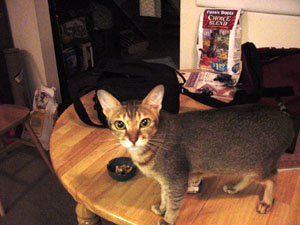

в датасете: Abyssinian
другие 83.8%

American Bulldog             0.1%
American Pit Bull Terrier    0.0%
Basset Hound                 0.0%
Beagle                       0.7%
Boxer                        0.0%
Chihuahua                    1.9%
English Cocker Spaniel       0.0%
English Setter               0.0%
German Shorthaired           0.0%
Great Pyrenees               0.0%
Havanese                     0.0%
Japanese Chin                0.0%
Keeshond                     0.0%
Leonberger                   0.1%
Miniature Pinscher           8.6%
Newfoundland                 0.0%
Pomeranian                   0.1%
Pug                          0.0%
Saint Bernard                0.0%
Samoyed                      0.0%
Scottish Terrier             0.2%
Shiba Inu                    4.3%
Staffordshire Bull Terrier   0.0%
Wheaten Terrier              0.0%
Yorkshire Terrier            0.1%
другие                       83.8%


In [48]:
other_index = next(
    i
    for i, old_y in enumerate(test_all._labels)
    if old_y not in old_to_new
)
other_image, old_y = test_all[other_index]

display(other_image)
print("в датасете:", test_all.classes[old_y])

class_id, probabilities = predict(other_image)
show_probabilities(class_id, probabilities)

фото: /Users/madmarchello/dev_projects/aisec-hse/python/lecture2/photos/Beagle_1.jpg
torch.Size([3, 224, 224])
torch.Size([1, 3, 224, 224])


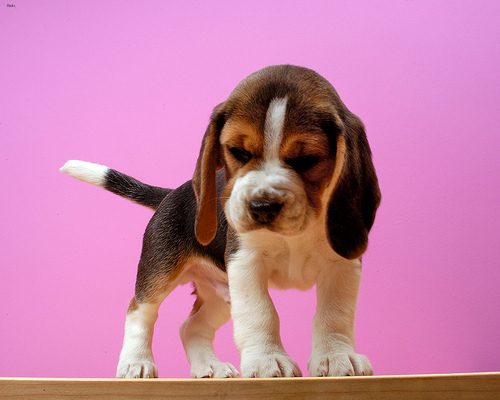

Beagle 95.0%

American Bulldog             0.1%
American Pit Bull Terrier    0.0%
Basset Hound                 0.6%
Beagle                       95.0%
Boxer                        0.0%
Chihuahua                    0.0%
English Cocker Spaniel       0.8%
English Setter               0.0%
German Shorthaired           0.0%
Great Pyrenees               0.0%
Havanese                     0.0%
Japanese Chin                0.1%
Keeshond                     0.0%
Leonberger                   0.1%
Miniature Pinscher           0.0%
Newfoundland                 0.0%
Pomeranian                   0.0%
Pug                          0.0%
Saint Bernard                3.2%
Samoyed                      0.0%
Scottish Terrier             0.0%
Shiba Inu                    0.0%
Staffordshire Bull Terrier   0.0%
Wheaten Terrier              0.0%
Yorkshire Terrier            0.0%
другие                       0.0%


In [49]:
photo_candidates = [
    image_path,
    Path("photos/Beagle_1.jpg"),
    Path("dog.jpg"),
]
photo_path = next(
    (path for path in photo_candidates if path.is_file()),
    None,
)
if photo_path is None:
    raise FileNotFoundError(
        "Нет снимка для распознавания. "
        f"Проверены: {', '.join(str(path.resolve()) for path in photo_candidates)}."
    )
image_path = photo_path
print("фото:", image_path.resolve())

image = Image.open(image_path).convert("RGB")
x = transform(image)
print(x.shape)  # [3, 224, 224]

x = x.unsqueeze(0)
print(x.shape)  # [1, 3, 224, 224]

display(image)
class_id, probabilities = predict(image)
show_probabilities(class_id, probabilities)

## Фото автомобиля

Машины в Oxford-IIIT Pet нет, и отдельного класса для неё сеть не учила. Ячейка ниже открывает `photos/car.jpg` и прогоняет его через тот же `predict`: 26 logits, softmax, класс с максимальной вероятностью.

Победитель всё равно один из 26 имён. «Другие» на обучении видели только кошек, поэтому доля у машины небольшая, даже если argmax попал в этот класс.


фото: /Users/madmarchello/dev_projects/aisec-hse/python/lecture2/photos/car.jpg


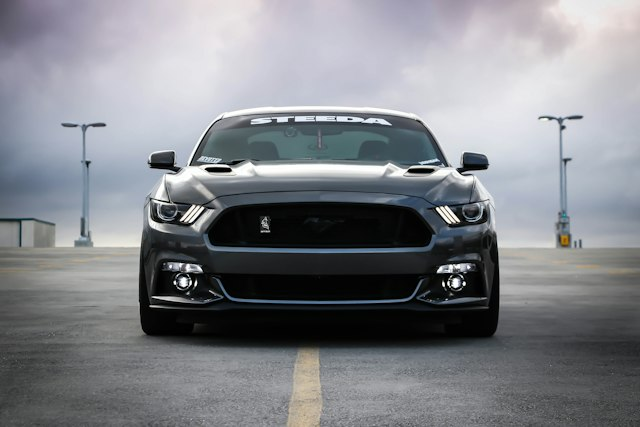

другие 21.8%

American Bulldog             16.3%
American Pit Bull Terrier    0.9%
Basset Hound                 0.2%
Beagle                       8.3%
Boxer                        0.1%
Chihuahua                    0.2%
English Cocker Spaniel       1.1%
English Setter               1.3%
German Shorthaired           0.5%
Great Pyrenees               0.0%
Havanese                     7.0%
Japanese Chin                1.9%
Keeshond                     7.2%
Leonberger                   2.7%
Miniature Pinscher           1.0%
Newfoundland                 0.3%
Pomeranian                   8.8%
Pug                          0.3%
Saint Bernard                0.4%
Samoyed                      1.3%
Scottish Terrier             0.4%
Shiba Inu                    3.6%
Staffordshire Bull Terrier   0.4%
Wheaten Terrier              0.1%
Yorkshire Terrier            14.2%
другие                       21.8%


In [50]:
car_path = Path("photos/car.jpg")
if not car_path.is_file():
    raise FileNotFoundError(
        f"Нет фото {car_path.resolve()}."
    )

car = Image.open(car_path).convert("RGB")
print("фото:", car_path.resolve())
display(car)

class_id, probabilities = predict(car)
show_probabilities(class_id, probabilities)


In [1]:
katya_dog_pth = Path("/Users/madmarchello/2026-10-01T16_32_33.314.jpeg")
if not katya_dog_pth.is_file():
    raise FileNotFoundError(
        f"Нет фото {katya_dog_pth.resolve()}."
    )

car = Image.open(katya_dog_pth).convert("RGB")
print("фото:", katya_dog_pth.resolve())
display(car)

class_id, probabilities = predict(car)
show_probabilities(class_id, probabilities)


NameError: name 'Path' is not defined